In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r'C:\Users\ASUS\OneDrive\Videos\Unsupervised-ML\03_Hierarchical_Clustering\data\cleaned_data.csv')

In [3]:
df.head()

,Country,"GDP (nominal, 2023)",GDP (abbrev.),GDP Growth,Population 2023,GDP per capita,Share of World GDP,GDP_log,Population_log,GDP_per_capita_log
0,United States,2.772070e+13,27.721 trillion,2.89,343477335,80706.0,26.11%,30.953201,19.654632,11.298581
1,China,1.779480e+13,17.795 trillion,5.25,1422584933,12509.0,16.76%,30.509927,21.075741,9.434284
2,Germany,4.525700e+12,4.526 trillion,-0.27,84548231,53528.0,4.26%,29.140793,18.252833,10.887979
3,Japan,4.204490e+12,4.204 trillion,1.68,124370947,33806.0,3.96%,29.067174,18.638779,10.428423
4,India,3.567550e+12,3.568 trillion,8.15,1438069596,2481.0,3.36%,28.902900,21.086567,7.816820


### We will train two models, one before transformation and one after

In [4]:
X_before = df[['GDP (nominal, 2023)', 
               'Population 2023', 
               'GDP per capita', 
               'GDP Growth']]

In [5]:
X_after = df[['GDP_log', 
              'Population_log', 
              'GDP_per_capita_log', 
              'GDP Growth']]

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# BEFORE scaling
X_before_scaled = scaler.fit_transform(X_before)

# AFTER scaling
X_after_scaled = scaler.fit_transform(X_after)

In [45]:
X_before_scaled

array([[ 1.08150998e+01,  1.93333948e+00,  2.71096131e+00,
        -5.65433624e-02],
       [ 6.86012782e+00,  8.89009642e+00, -2.23879357e-01,
         2.88254106e-01],
       [ 1.57305878e+00,  2.64083468e-01,  1.54136295e+00,
        -5.18221329e-01],
       [ 1.44507274e+00,  5.20811302e-01,  6.92631658e-01,
        -2.33325115e-01],
       [ 1.19128419e+00,  8.98992246e+00, -6.55431804e-01,
         7.11945911e-01],
       [ 1.11689362e+00,  1.61803751e-01,  1.35614139e+00,
        -4.29099949e-01],
       [ 9.85795701e-01,  1.47336300e-01,  1.21455707e+00,
        -3.41439576e-01],
       [ 6.86603798e-01,  1.02599794e-01,  9.02038739e-01,
        -3.76503725e-01],
       [ 6.35893104e-01,  1.08019601e+00, -3.19158288e-01,
        -5.36213499e-02],
       [ 6.23461473e-01, -2.76271748e-02,  1.58392431e+00,
        -2.96148383e-01],
       [ 5.75229135e-01,  6.56641834e-01, -1.64061058e-01,
         4.71880794e-02],
       [ 4.82665283e-01,  5.55422791e-01, -1.68751846e-01,
      

In [46]:
X_after_scaled

array([[ 2.70048821e+00,  1.81614426e+00,  1.67525772e+00,
        -5.65433624e-02],
       [ 2.50972602e+00,  2.47902265e+00,  3.63679555e-01,
         2.88254106e-01],
       [ 1.92052046e+00,  1.16227341e+00,  1.38638943e+00,
        -5.18221329e-01],
       [ 1.88883848e+00,  1.34229860e+00,  1.06308086e+00,
        -2.33325115e-01],
       [ 1.81814335e+00,  2.48407248e+00, -7.74245363e-01,
         7.11945911e-01],
       [ 1.79501125e+00,  1.06533505e+00,  1.32741866e+00,
        -4.29099949e-01],
       [ 1.75094964e+00,  1.04983973e+00,  1.27875288e+00,
        -3.41439576e-01],
       [ 1.62940887e+00,  9.98383422e-01,  1.15768644e+00,
        -3.76503725e-01],
       [ 1.60492169e+00,  1.58917084e+00,  2.26652126e-01,
        -5.36213499e-02],
       [ 1.59869987e+00,  8.04915607e-01,  1.39926910e+00,
        -2.96148383e-01],
       [ 1.57367114e+00,  1.41529750e+00,  4.37803234e-01,
         4.71880794e-02],
       [ 1.52113329e+00,  1.36201176e+00,  4.32264645e-01,
      

In [ ]:
print(np.mean(X_after_scaled, axis=0))  # ~0
print(np.std(X_after_scaled, axis=0))   # ~1

[-1.17769514e-15  5.10334562e-16  1.96282524e-16  3.92565047e-17]
[1. 1. 1. 1.]


In [47]:
from sklearn.cluster import AgglomerativeClustering

# BEFORE transformation
model_before = AgglomerativeClustering(n_clusters=3, linkage='ward') # linkage, method to calculate distance between two clusters
labels_before = model_before.fit_predict(X_before_scaled)

# AFTER transformation
model_after = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_after = model_after.fit_predict(X_after_scaled)

In [48]:
df['cluster_before'] = labels_before # Clusterd using model before transformation of columns  
df['cluster_after'] = labels_after # Clusterd using model after transformation of columns   

In [61]:
df['cluster_before'].value_counts()

cluster_before
2    153
0     25
1      3
Name: count, dtype: int64

In [60]:
df['cluster_after'].value_counts()

cluster_after
0    118
1     61
2      2
Name: count, dtype: int64

In [49]:
df.head()

,Country,"GDP (nominal, 2023)",GDP (abbrev.),GDP Growth,Population 2023,GDP per capita,Share of World GDP,GDP_log,Population_log,GDP_per_capita_log,cluster_before,cluster_after,cluster_final
0,United States,2.772070e+13,27.721 trillion,2.89,343477335,80706.0,26.11%,30.953201,19.654632,11.298581,1,1,1
1,China,1.779480e+13,17.795 trillion,5.25,1422584933,12509.0,16.76%,30.509927,21.075741,9.434284,1,1,1
2,Germany,4.525700e+12,4.526 trillion,-0.27,84548231,53528.0,4.26%,29.140793,18.252833,10.887979,0,1,1
3,Japan,4.204490e+12,4.204 trillion,1.68,124370947,33806.0,3.96%,29.067174,18.638779,10.428423,0,1,1
4,India,3.567550e+12,3.568 trillion,8.15,1438069596,2481.0,3.36%,28.902900,21.086567,7.816820,1,1,1


In [50]:
df[['Country', 'cluster_before', 'cluster_after']].head(40)

,Country,cluster_before,cluster_after
0,United States,1,1
1,China,1,1
2,Germany,0,1
3,Japan,0,1
4,India,1,1
5,United Kingdom,0,1
6,France,0,1
7,Italy,2,1
8,Brazil,2,1
9,Canada,0,1


In [51]:
df[['Country', 'cluster_before', 'cluster_after']].tail(40)

,Country,cluster_before,cluster_after
141,Namibia,2,0
142,Equatorial Guinea,2,0
143,Tajikistan,2,0
144,Mauritania,2,0
145,Togo,2,0
146,Montenegro,2,0
147,Barbados,2,0
148,Maldives,2,0
149,Sierra Leone,2,0
150,Fiji,2,0


In [52]:
df[df['Country'] == 'India']

,Country,"GDP (nominal, 2023)",GDP (abbrev.),GDP Growth,Population 2023,GDP per capita,Share of World GDP,GDP_log,Population_log,GDP_per_capita_log,cluster_before,cluster_after,cluster_final
4,India,3.567550e+12,3.568 trillion,8.15,1438069596,2481.0,3.36%,28.9029,21.086567,7.81682,1,1,1


In [53]:
## india is in cluster no. 1, so which countries are within same clusters
india_cluster = df[df['Country'] == 'India']['cluster_after'].values[0]

df[df['cluster_after'] == india_cluster][['Country', 'GDP per capita', 'Population 2023']]

# there are 61 countries out of 180 counties which belongs to same cluster as india

,Country,GDP per capita,Population 2023
0,United States,80706.0,343477335
1,China,12509.0,1422584933
2,Germany,53528.0,84548231
3,Japan,33806.0,124370947
4,India,2481.0,1438069596
...,...,...,...
56,Ukraine,4737.0,37732836
59,Morocco,3829.0,37712505
62,Ecuador,6610.0,17980083
66,Guatemala,5763.0,18124838


### India is clustered with countries having moderate GDP per capita and large population, indicating similarity in developing economies.

In [54]:
india_cluster

np.int64(1)

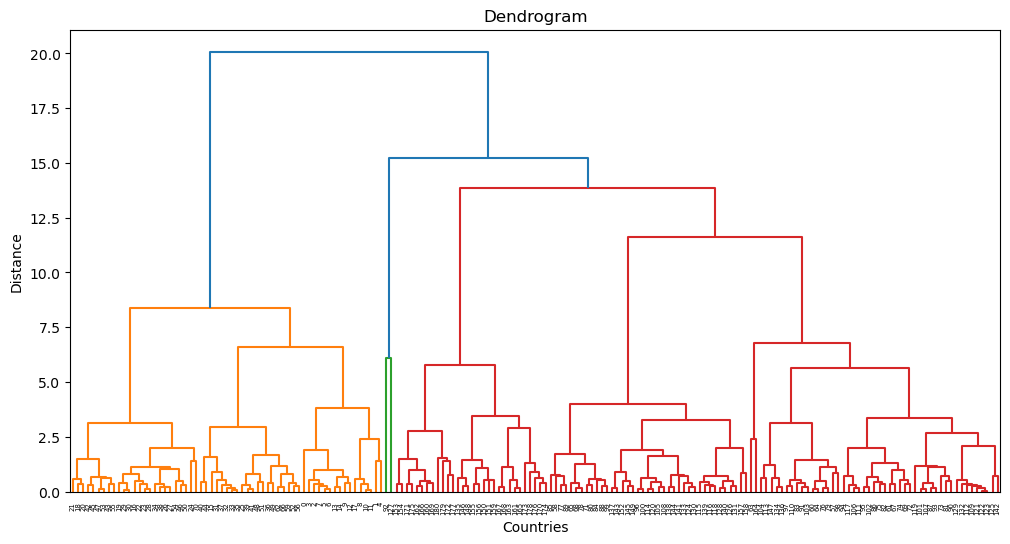

In [55]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z = linkage(X_after_scaled, method='ward')

plt.figure(figsize=(12,6))
dendrogram(Z)
plt.title("Dendrogram")
plt.xlabel("Countries")
plt.ylabel("Distance")
plt.show()

In [56]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_after_scaled)

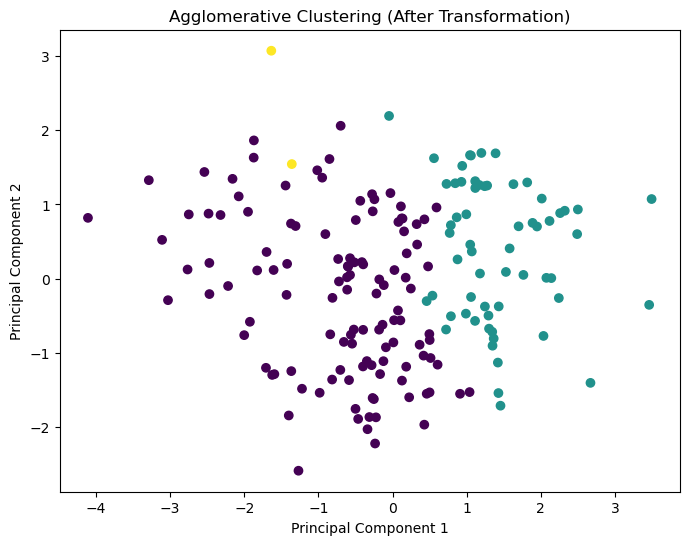

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster_final'], cmap='viridis')

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Agglomerative Clustering (After Transformation)")
plt.show()

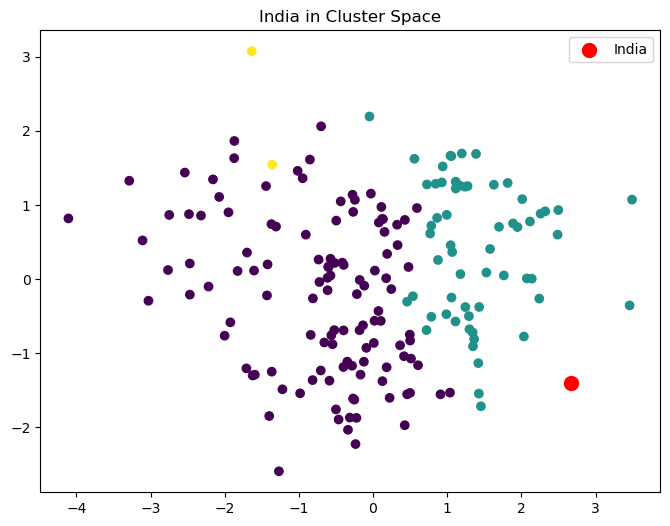

In [58]:
india_index = df[df['Country'] == 'India'].index[0]

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster_final'], cmap='viridis')

# Highlight India
plt.scatter(X_pca[india_index, 0], X_pca[india_index, 1], 
            color='red', s=100, label='India')

plt.legend()
plt.title("India in Cluster Space")
plt.show()